# High Resolution Cross Correlation Python Notebook

Solar Gravitational Lens

Author: Zane Collins

Date: Jan 23, 2025

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.path import Path
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import PathPatch, Rectangle
from scipy.spatial import cKDTree
from scipy.interpolate import interp1d
from pyhdf.SD import SD, SDC
from matplotlib.widgets import Button

from hapi import *
from pylab import show,plot,subplot,xlim,ylim,title,legend,xlabel,ylabel

from scipy.signal import correlate, find_peaks, savgol_filter, peak_widths
from scipy import signal

#File Parsing and Handling
import glob
import os

%matplotlib widget

HAPI version: 1.2.2.4
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

# Helper Functions

In [ ]:
#Extracts name from file path
def extract_name(file):
    base = os.path.basename(file)#Returns final component of a pathname
    name, ext = os.path.splitext(base)
    return name

def get_wn_range_and_intensities(filepath):
    intensities = []
    with open(filepath, 'r') as f:
        first_line = f.readline()
        tokens = first_line.split()
        floats = []
        for t in tokens:
            try:
                floats.append(float(t))
            except:
                pass
        wn_start, wn_end = floats[0], floats[1]
        for line in f:
            for val in line.split():
                try:
                    intensity = float(val.replace('D','E'))
                    intensity = np.clip(intensity, 1e-25, None)  # avoid log(0)
                    intensities.append(intensity)
                except ValueError:
                    pass
    return wn_start, wn_end, np.array(intensities)

def load_cross_section_file(filepath):
    """
    For lbl files
    """
    data = np.genfromtxt(filepath, delimiter=' ', comments='#')
    wn_grid = data[:,0]
    intensities = data[:,1]
    wavelength_grid = 1e4 / wn_grid
    return wavelength_grid, intensities

def load_intensity_hapi(molecule_formula):
    """
    For HAPI database
    """
    nu = getColumn(molecule_formula, 'nu')  # Wavenumber in cm^-1
    intensity = getColumn(molecule_formula, 'sw')  # Intensity in cm/molecule
    wavelength = 1e4 / nu  # Convert to microns
    wl_step = wavelength[0] - wavelength[1]
    return wavelength, intensity, wl_step

def generate_transmittance_absorbance(
    table_name, molecule_number,
    wavelength_min, wavelength_max,
    dwn,              # cm^-1 sampling step
    T=296.0, p=1.0,        # K, atm
    L_cm=10.0              # path length in cm
):
    iso = 1
    wn_min = 1e4 / wavelength_max
    wn_max = 1e4 / wavelength_min

    # Download the line list (cached locally by HAPI)
    fetch(table_name, molecule_number, iso, wn_min, wn_max)

    # Absorption coefficient alpha(wn) in cm^-1 on a uniform wn grid
    # wn_grid, alpha = absorptionCoefficient_Voigt(
    #     SourceTables=table_name,
    #     WavenumberRange=(wn_min, wn_max),
    #     WavenumberStep=dwn,
    #     Environment={'T': T, 'p': p}
    # )

    wn_grid, alpha = absorptionCoefficient_Voigt(
    SourceTables=table_name,
    WavenumberRange=(wn_min, wn_max),
    WavenumberStep=dwn,
    Environment={'T': T, 'p': p}
    )

    # scale by column density (molecules/cm^2)
    N = 2.5e19  # example; choose based on your scenario
    tau = alpha * N


    # Beer–Lambert
    # absorbance = np.exp(-alpha * L_cm)
    transmittance = np.exp(-tau)

    # Base-10 absorbance
    absorbance = -np.log10(transmittance)  # = alpha*L_cm/ln(10)

    wavelength_grid = 1e4 / wn_grid

    #Compute spectral resolution
    dnu = np.median(np.diff(wn_grid))  # cm^-1
    R_nu = wn_grid / dnu               # dimensionless

    return wavelength_grid, wn_grid, transmittance, absorbance, R_nu

def generate_absorbance_library(molecule_indices, lam_min_um, lam_max_um, dwn):
    """
    Generate absorbance spectra once per molecule.

    Returns:
        spectra[molecule] = {
            "wavelength": np.ndarray (µm),
            "wavenumber": np.ndarray (cm^-1),
            "absorbance": np.ndarray,
            "spec_res": float
        }
    """
    spectra = {}

    for molecule, idx in molecule_indices.items():
        print("Trying:", molecule, idx)
        wavelength, wn_grid, trans, absorbance, spec_res = (
            generate_transmittance_absorbance(
                molecule, idx, lam_min_um, lam_max_um, dwn
            )
        )

        spectra[molecule] = {
            "wavelength": np.asarray(wavelength),
            "wavenumber": np.asarray(wn_grid),
            "absorbance": np.asarray(absorbance),
            "spec_res": spec_res,
        }

        print(
            f"{molecule}: "
            f"λ = {spectra[molecule]['wavelength'].min():.3f}–{spectra[molecule]['wavelength'].max():.3f} µm, "
            f"abs max = {spectra[molecule]['absorbance'].max():.3e}"
        )

    return spectra


#Normalizing Spectrum

def normalize_spectrum(spectrum, eps=1e-30):
    s0 = spectrum - np.mean(spectrum)
    n0 = np.linalg.norm(s0)
    if n0 < eps:
        return np.zeros_like(spectrum)
    return s0 / n0

def highpass(spectrum, window=51, polyorder=4): #Fits a polynomial to each point, considering the surrounding points in a set window 
    trend = savgol_filter(spectrum, window_length=window, polyorder=polyorder)
    return spectrum - trend


#Add Poisson Noise based on SNR
def add_poisson_noise_snr(T, snr):
    noise = np.random.normal(0, 1/snr, size=T.shape) #Mean = 0, Standard Deviation = 1/SNR, Normal indicates gaussian distribution, size=T.shape ensures noise array matches T array in size
    return T + noise

def find_troughs_wn(wn, y, smooth=False, window=31, poly=3,
                    prominence=None, distance=None):
    """
    Return sorted wavenumbers (cm^-1) where y has troughs (local minima).
    """
    wn = np.asarray(wn)
    y = np.asarray(y)

    # Ensure increasing wn
    if wn[0] > wn[-1]:
        wn = wn[::-1]
        y = y[::-1]

    # Optional smoothing (helps a lot with noisy spectra)
    if smooth:
        window = int(window)
        if window % 2 == 0:
            window += 1
        window = min(window, len(y) - (1 - len(y) % 2))
        if window >= 5:
            y = savgol_filter(y, window_length=window, polyorder=poly)

    idx, _ = find_peaks(y, prominence=prominence, distance=distance)
    return np.sort(wn[idx]) #This returns wavenumber indices where peaks are located

def nearest_neighbor_deltas(a, b, max_delta=None):
    """
    For each a[i], find nearest b[j] in wavenumber and return |a-b|.
    Optionally discard matches with |Δwn| > max_delta.
    """
    a = np.asarray(a)
    b = np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.array([])

    b = np.sort(b)
    j = np.searchsorted(b, a)

    j0 = np.clip(j - 1, 0, len(b) - 1)
    j1 = np.clip(j,     0, len(b) - 1)

    d0 = np.abs(a - b[j0])
    d1 = np.abs(a - b[j1])
    d = np.minimum(d0, d1)

    if max_delta is not None:
        d = d[d <= max_delta]
    return d

def symmetric_adjacent_trough_deltas(troughs1, troughs2, max_delta=None):
    """
    "Adjacent across spectra" deltas from 1->2 plus 2->1.
    """
    d12 = nearest_neighbor_deltas(troughs1, troughs2, max_delta=max_delta)
    d21 = nearest_neighbor_deltas(troughs2, troughs1, max_delta=max_delta)
    return np.concatenate([d12, d21])


def trough_delta_stats_wn(wn1, y1, wn2, y2,
                          smooth=True, window=31, poly=3,
                          prominence=None, distance=None,
                          max_delta=None):
    t1 = find_troughs_wn(wn1, y1, smooth=smooth, window=window, poly=poly,
                         prominence=prominence, distance=distance)
    t2 = find_troughs_wn(wn2, y2, smooth=smooth, window=window, poly=poly,
                         prominence=prominence, distance=distance)

    d = symmetric_adjacent_trough_deltas(t1, t2, max_delta=max_delta)

    if len(d) == 0:
        return {
            "n_troughs_1": int(len(t1)),
            "n_troughs_2": int(len(t2)),
            "n_pairs": 0,
            "min_dwn": np.nan,
            "max_dwn": np.nan,
            "mean_dwn": np.nan,
        }

    return {
        "n_troughs_1": int(len(t1)),
        "n_troughs_2": int(len(t2)),
        "n_pairs": int(len(d)),
        "min_dwn": float(np.min(d)),
        "max_dwn": float(np.max(d)),
        "mean_dwn": float(np.mean(d)),
    }

#IMPROVEMENTS

def nearest_neighbor_indices(a, b):
    """
    For each value in a, return the index of the nearest value in sorted(b).
    a and b are 1D arrays of wavenumbers (cm^-1).
    Returns indices into b.
    """
    a = np.asarray(a)
    b = np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.array([], dtype=int)

    b = np.sort(b)
    j = np.searchsorted(b, a)

    j0 = np.clip(j - 1, 0, len(b) - 1)
    j1 = np.clip(j,     0, len(b) - 1)

    d0 = np.abs(a - b[j0])
    d1 = np.abs(a - b[j1])

    return np.where(d0 <= d1, j0, j1)

def mutual_nearest_neighbor_deltas(t1, t2, max_delta=None):
    """
    t1, t2: sorted arrays of trough wavenumbers (cm^-1).
    Returns:
      deltas: |Δwn| for mutual NN pairs
      pairs:  list of (i, j) indices meaning t1[i] matched to t2[j]
    """
    t1 = np.sort(np.asarray(t1))
    t2 = np.sort(np.asarray(t2))
    if len(t1) == 0 or len(t2) == 0:
        return np.array([]), []

    # For each trough in t1, find nearest in t2
    j_for_i = nearest_neighbor_indices(t1, t2)

    # For each trough in t2, find nearest in t1
    i_for_j = nearest_neighbor_indices(t2, t1)

    pairs = []
    deltas = []

    # Mutual condition: i -> j and j -> i
    for i, j in enumerate(j_for_i):
        if i_for_j[j] == i:
            d = abs(t1[i] - t2[j])
            if (max_delta is None) or (d <= max_delta):
                pairs.append((i, j))
                deltas.append(d)

    return np.asarray(deltas), pairs


def delta_stats(deltas):
    if len(deltas) == 0:
        return {"n_pairs": 0, "min": np.nan, "max": np.nan, "mean": np.nan}
    return {
        "n_pairs": int(len(deltas)),
        "min": float(np.min(deltas)),
        "max": float(np.max(deltas)),
        "mean": float(np.mean(deltas)),
        "median": float(np.median(deltas)),
        "Standard Deviation": float(np.std(deltas)),
        "10th percentile": float(np.percentile(deltas, 10)),
    }

#FWHM

def fwhm_per_peak(wn, y, prominence=0.03, min_sep_wn=0.2,
                  smooth=True, window=31, poly=3):
    """
    Return arrays: peak_wn, fwhm_wn for peaks in y(wn).
    wn must be increasing in cm^-1.
    """
    wn = np.asarray(wn)
    y  = np.asarray(y)

    if wn[0] > wn[-1]:
        wn = wn[::-1]
        y  = y[::-1]

    if smooth:
        window = int(window)
        if window % 2 == 0:
            window += 1
        window = min(window, len(y) - (1 - len(y) % 2))
        if window >= 5:
            y = savgol_filter(y, window_length=window, polyorder=poly)

    dwn = float(np.median(np.diff(wn)))
    distance = max(1, int(min_sep_wn / dwn))

    peaks, _ = find_peaks(y, prominence=prominence, distance=distance)

    # widths returned in "samples"; we convert to wavenumber via interpolation
    widths_samp, h_eval, left_ips, right_ips = peak_widths(y, peaks, rel_height=0.5)

    # Convert fractional indices (left_ips/right_ips) -> wavenumber using interpolation
    idx = np.arange(len(wn))
    left_wn  = np.interp(left_ips,  idx, wn)
    right_wn = np.interp(right_ips, idx, wn)

    fwhm = right_wn - left_wn
    peak_wn = wn[peaks]

    return peak_wn, fwhm

def peak_stats(peak_wn, fwhm_wn):
    if len(peak_wn) == 0:
        return {
            "n_peaks": 0,
            "min_fwhm": np.nan,
            "max_fwhm": np.nan,
            "mean_fwhm": np.nan,
        }
    return {
        "n_peaks": int(len(peak_wn)),
        "min_fwhm": float(np.min(fwhm_wn)),
        "max_fwhm": float(np.max(fwhm_wn)),
        "mean_fwhm": float(np.mean(fwhm_wn)),
        "median_fwhm": float(np.median(fwhm_wn)),
        "std_fwhm": float(np.std(fwhm_wn)),
        "90th percentile": float(np.percentile(fwhm_wn, 90)),
    }


#Generate fake spectrum of similar structure, shifted by set amount

import numpy as np




# Parsing

## Choose local database folder

In [ ]:
db_begin('HAPI_DB')

Using HAPI_DB

H20
                     Lines parsed: 58143
SO3_iso1_1.670-16.670um
                     Lines parsed: 3541
SO2
                     Lines parsed: 350816
SO2_iso1_1.670-16.670um
                     Lines parsed: 350816
SO
                     Lines parsed: 40527
H2S_iso1_1.670-16.670um
                     Lines parsed: 67541
OCS
                     Lines parsed: 459210
SO3
                     Lines parsed: 3541
H2O
                     Lines parsed: 54683
CO2
                     Lines parsed: 132426
CS
                     Lines parsed: 593
CS2
                     Lines parsed: 280983
H2S
                     Lines parsed: 67541


## Parsing Template Spectrum

In [ ]:
lam_min = 1.67
lam_max = 16.67

In [ ]:
template_molecule = f"SO3_iso1_{lam_min:.3f}-{lam_max:.3f}um"

template_molecule_index = 47

template_wavelength, template_wn_grid, template_transmittance, template_absorbance, template_spec_res = generate_transmittance_absorbance(template_molecule, template_molecule_index, 1.6, 16.6667)

print(f'Generated {template_molecule} Resolution: ', template_spec_res)



Data is fetched from http://hitran.org

BEGIN DOWNLOAD: SO3_iso1_1.670-16.670um
  65536 bytes written to HAPI_DB/SO3_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO3_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO3_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO3_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO3_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO3_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO3_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO3_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO3_iso1_1.670-16.670um.data
Header written to HAPI_DB/SO3_iso1_1.670-16.670um.header
END DOWNLOAD
                     Lines parsed: 3541
PROCESSED
{'air': 1.0}
1.054265 seconds elapsed for abscoef; nlines = 3541
Generated SO3_iso1_1.670-16.670um Resolution:  [ 599998.79988016  599999.79988016  600000.79988016 ... 6249997.79872911
 6249998.79872911 6249999.79872911]


## Parsing Test Spectrum

In [ ]:
test_molecule = f'SO2_iso1_{lam_min:.3f}-{lam_max:.3f}um'
test_molecule_index = 9
test_wavelength, test_wn_grid, test_transmittance, test_absorbance, test_spec_res = generate_transmittance_absorbance(test_molecule, test_molecule_index, 1.6, 16.6667)

print(f'Generated {test_molecule} Resolution: ', test_spec_res)


Data is fetched from http://hitran.org

BEGIN DOWNLOAD: SO2_iso1_1.670-16.670um
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.670um.data
  65536 bytes written to HAPI_DB/SO2_iso1_1.670-16.

KeyboardInterrupt: 

## Incorporating Poisson (Shot Noise)

In [ ]:
snr = 100

# template_transmittance_noisy = add_poisson_noise_snr(template_transmittance, snr)
# test_transmittance_noisy = add_poisson_noise_snr(test_transmittance, snr)

template_absorbance_noisy = add_poisson_noise_snr(template_absorbance, snr)
test_absorbance_noisy = add_poisson_noise_snr(test_absorbance, snr)

## Cross Correlation

### Normalizing Spectrum

### Noisless

In [ ]:
# template_transmittance_normalized = normalize_spectrum(template_transmittance)
# test_transmittance_normalized = normalize_spectrum(test_transmittance)

template_absorbance_normalized = normalize_spectrum(template_absorbance)
test_absorbance_normalized = normalize_spectrum(test_absorbance)

### Noisy

In [ ]:
# template_transmittance_noisy_normalized = normalize_spectrum(template_transmittance_noisy)
# test_transmittance_noisy_normalized = normalize_spectrum(test_transmittance_noisy)

template_absorbance_noisy_normalized = normalize_spectrum(template_absorbance_noisy)
test_absorbance_noisy_normalized = normalize_spectrum(test_absorbance_noisy)

In [ ]:
print(np.max(test_spec_res))

6249999.798729108


## Cross Correlating

I perform cross correlation on the normalized spectra

### Noiseless Cross Correlation

In [ ]:
#Correlate function returns an array of cross-correlation values for different shifts k of the template with respect to the test spectrum 
# cross_correlation_vector = correlate(template_transmittance_normalized, test_transmittance_normalized, mode='full')

# lags = signal.correlation_lags(len(template_transmittance_normalized), len(test_transmittance_normalized), mode='full')
# lag_0 = len(template_transmittance_normalized) - 1
# max_shift = 10000  # maximum shift, physically motivated
# mask = np.abs(lags) <= max_shift

# similarity_noiseless = cross_correlation_vector[mask].max()

cross_correlation_vector = correlate(template_absorbance_normalized, test_absorbance_normalized, mode='full')

lags = signal.correlation_lags(len(template_absorbance_normalized), len(test_absorbance_normalized), mode='full')
lag_0 = len(template_absorbance_normalized) - 1
max_shift = 100  # maximum shift, physically motivated
mask = np.abs(lags) <= max_shift

similarity_noiseless = cross_correlation_vector[mask].max()


### Noisy Cross Correlation

In [ ]:
# cross_correlation_vector_noisy = correlate(template_transmittance_noisy_normalized, test_transmittance_noisy_normalized, mode='full')

# lags_noisy = signal.correlation_lags(len(template_transmittance_noisy_normalized), len(test_transmittance_noisy_normalized), mode='full')
# lag_0_noisy = len(template_transmittance_noisy_normalized) - 1
# max_shift_noisy = 10000  # maximum shift, physically motivated
# mask_noisy = np.abs(lags_noisy) <= max_shift_noisy

# similarity_noisy = np.max(cross_correlation_vector_noisy[mask_noisy])

cross_correlation_vector_noisy = correlate(template_absorbance_noisy_normalized, test_absorbance_noisy_normalized, mode='full')

lags_noisy = signal.correlation_lags(len(template_absorbance_noisy_normalized), len(test_absorbance_noisy_normalized), mode='full')
lag_0_noisy = len(template_absorbance_noisy_normalized) - 1
max_shift_noisy = 100  # maximum shift, physically motivated
mask_noisy = np.abs(lags_noisy) <= max_shift_noisy

similarity_noisy = np.max(cross_correlation_vector_noisy[mask_noisy])

In [ ]:
# # print("Cross-Correlation Vector:", cross_correlation_vector)
# # print('maximum cross correlation value index is ', np.argmax(cross_correlation_vector))
# print('similarity (noiseless): ', similarity_noiseless)
# print('maximum possible similarity (noiseless) is ', np.max(template_transmittance*test_transmittance))
# # print('cross correlation value at zero lag is ', cross_correlation_vector[len(template_intensity)//2])

# print('Similarity (noisy): ', similarity_noisy)
# print('Maximum possible similarity (noisy) is ', np.max(template_transmittance_noisy*test_transmittance_noisy))

# print('SNR (Noisy)= ' , np.max(cross_correlation_vector_noisy[mask_noisy]) / np.std(cross_correlation_vector_noisy[mask_noisy]))
# print('SNR (Noiseless) =' , np.max(cross_correlation_vector[mask]) / np.std(cross_correlation_vector[mask]))

# print("Cross-Correlation Vector:", cross_correlation_vector)
# print('maximum cross correlation value index is ', np.argmax(cross_correlation_vector))
print('similarity (noiseless): ', similarity_noiseless)
# print('cross correlation value at zero lag is ', cross_correlation_vector[len(template_intensity)//2])

print('Similarity (noisy): ', similarity_noisy)
print('SNR (Noisy)= ' , np.max(cross_correlation_vector_noisy[mask_noisy]) / np.std(cross_correlation_vector_noisy[mask_noisy]))
print('SNR (Noiseless) =' , np.max(cross_correlation_vector[mask]) / np.std(cross_correlation_vector[mask]))

print('max possible cross correlation = 1')


similarity (noiseless):  0.33771884297733534
Similarity (noisy):  0.33765274611935003
SNR (Noisy)=  202.85624970266312
SNR (Noiseless) = 202.72192160459915
max possible cross correlation = 1


In [ ]:
# prom = 0.06
# dist = 5

# t1 = find_troughs_wn(template_wn_grid, template_transmittance_noisy, prominence=prom, distance=dist)
# t2 = find_troughs_wn(template_wn_grid, test_transmittance_noisy, prominence=prom, distance=dist)

# deltas, pairs = mutual_nearest_neighbor_deltas(t1, t2, max_delta=0.5)
# stats = delta_stats(deltas)

# print(stats)

prom = 0.06
dist = 5

t1 = find_troughs_wn(template_wn_grid, template_absorbance_noisy, prominence=prom, distance=dist)
t2 = find_troughs_wn(template_wn_grid, test_absorbance_noisy, prominence=prom, distance=dist)

deltas, pairs = mutual_nearest_neighbor_deltas(t1, t2, max_delta=0.5)
stats = delta_stats(deltas)

print(stats)



{'n_pairs': 3522, 'min': 0.0, 'max': 0.5, 'mean': 0.16796905167518367, 'median': 0.14200000000118962, 'Standard Deviation': 0.12452507350516194, '10th percentile': 0.024999999999886315}


Here, I constrain to the overlapping wavenumber region - 1350 to 1400 cm^-1

In [ ]:
wn_lo, wn_hi = 1350, 1400  # cm^-1

mask = (template_wn_grid >= wn_lo) & (template_wn_grid <= wn_hi)
wn_cut = template_wn_grid[mask]
template_absorbance_cut  = template_absorbance_noisy[mask]
test_absorbance_cut  = test_absorbance_noisy[mask]


t1 = find_troughs_wn(wn_cut, template_absorbance_cut, prominence=prom, distance=dist)
t2 = find_troughs_wn(wn_cut, test_absorbance_cut, prominence=prom, distance=dist)


deltas, pairs = mutual_nearest_neighbor_deltas(t1, t2, max_delta=0.5)
stats = delta_stats(deltas)

stats_fwhm = peak_stats(*fwhm_per_peak(wn_cut, template_absorbance_cut, prominence=prom, min_sep_wn=0.2))


print(stats)
print(stats_fwhm)

{'n_pairs': 85, 'min': 0.0009999999997489795, 'max': 0.2619999999999436, 'mean': 0.08508235294114938, 'median': 0.07599999999979445, 'Standard Deviation': 0.057570051806931276, '10th percentile': 0.013999999999896318}
{'n_peaks': 89, 'min_fwhm': 0.026861906672138502, 'max_fwhm': 4.7472631646026, 'mean_fwhm': 0.2781104550584827, 'median_fwhm': 0.1744915753672558, 'std_fwhm': 0.5159326459595984, '90th percentile': 0.4580371691352412}


In [ ]:
print(np.where(deltas == 0.0))
print(deltas[21])
print(pairs[21])

print(t1[22],t2[41])

(array([], dtype=int64),)
0.16000000000008185
(24, 38)
1366.2748000024 1369.1388000023999


In [ ]:
# plt.figure(figsize=(10, 4))
# plt.hist(deltas, bins=50)
# plt.xlabel(r"$|\Delta \tilde{\nu}|$ (cm$^{-1}$)")
# plt.ylabel("Count")
# plt.title("Mutual NN trough differences")
# plt.tight_layout()
# plt.show()

# Plotting

## Absorbance

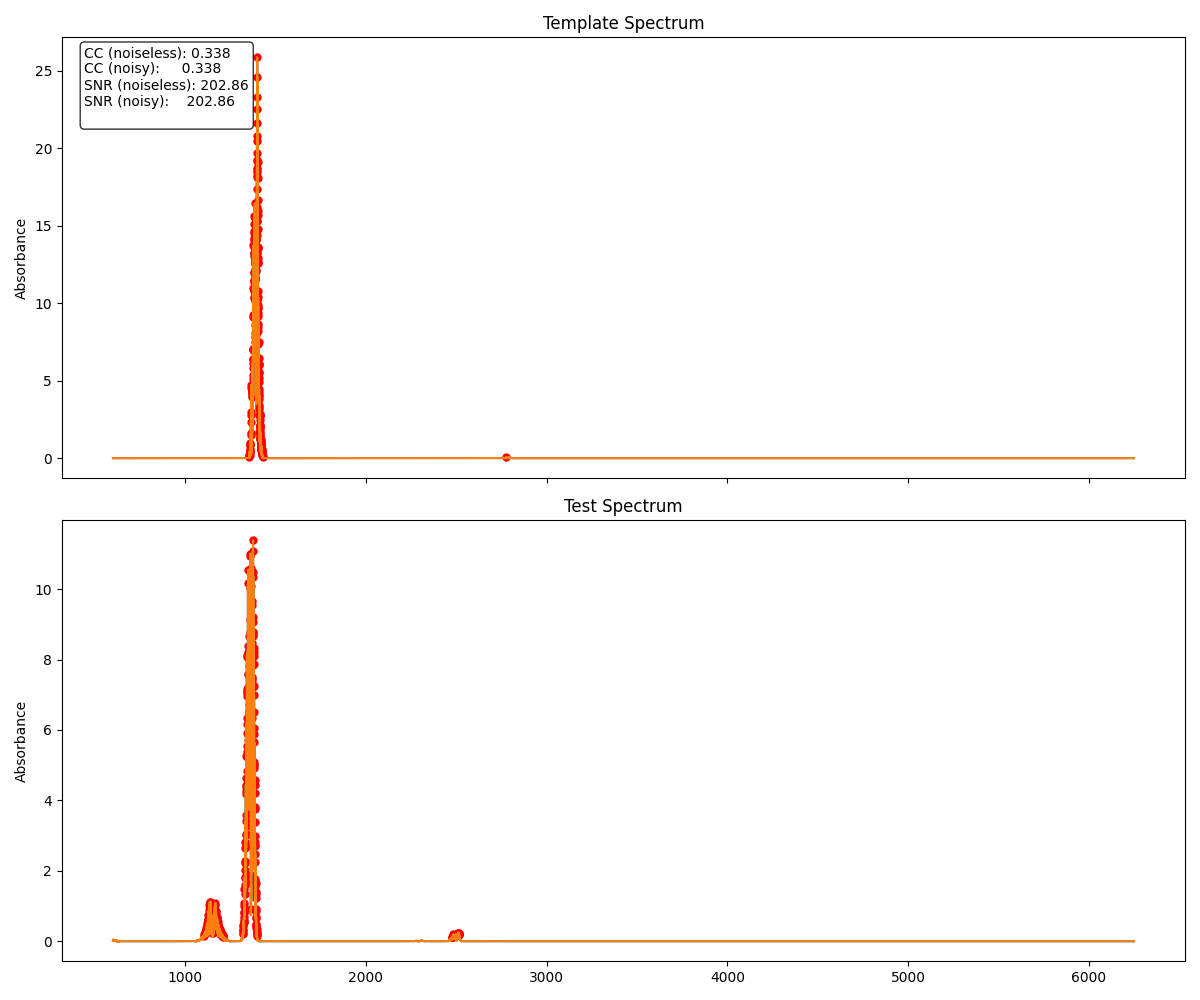

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

test_peaks = find_troughs_wn(template_wn_grid, test_absorbance, prominence=prom, distance=dist)
test_peaks_absorbance = [test_absorbance[np.where(template_wn_grid == wn)[0][0]] for wn in test_peaks]

template_peaks = find_troughs_wn(template_wn_grid, template_absorbance, prominence=prom, distance=dist)
template_peaks_absorbance = [template_absorbance[np.where(template_wn_grid == wn)[0][0]] for wn in template_peaks]

# fig.suptitle('Spectra for Cross-Correlation')

axs[0].plot(template_wn_grid, template_absorbance)
axs[0].set_ylabel('Absorbance')
axs[0].set_title('Template Spectrum')

axs[0].plot(template_wn_grid, template_absorbance, label="Template")
axs[0].scatter(
    template_peaks,
    template_peaks_absorbance,
    s=25, marker="o", color="red", label="Detected peaks"
)


axs[1].plot(template_wn_grid, test_absorbance)
axs[1].set_ylabel('Absorbance')
axs[1].set_title('Test Spectrum')

axs[1].plot(template_wn_grid, test_absorbance, label="Test")
axs[1].scatter(
    test_peaks,
    test_peaks_absorbance,
    s=25, marker="o", color="red", label="Detected peaks"
)


cc_text = (
    f"CC (noiseless): {similarity_noiseless:.3g}\n"
    f"CC (noisy):     {similarity_noisy:.3g}\n"
    f"SNR (noiseless): {np.max(cross_correlation_vector_noisy[mask_noisy]) / np.std(cross_correlation_vector_noisy[mask_noisy]):.2f}\n"
    f"SNR (noisy):    {np.max(cross_correlation_vector_noisy[mask_noisy]) / np.std(cross_correlation_vector_noisy[mask_noisy]):.2f}\n"
)

axs[0].text(
    0.02, 0.98, cc_text,
    transform=axs[0].transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)


plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 1, 0.96])  # leaves room for suptitle


### Noisy Plots

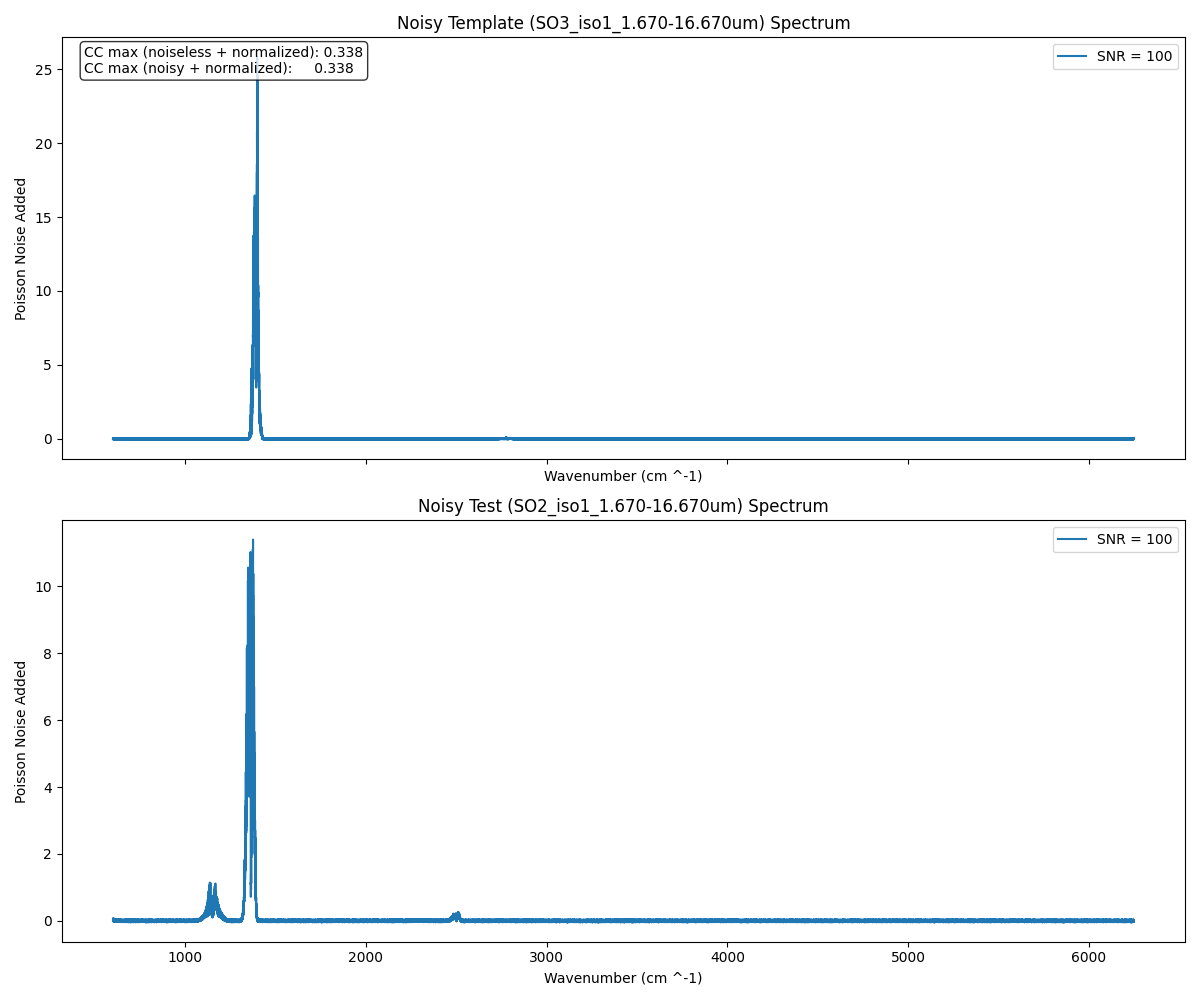

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# fig.suptitle('Spectra for Cross-Correlation')

axs[0].plot(template_wn_grid, template_absorbance_noisy, label = f'SNR = {snr}')
axs[0].set_ylabel('Poisson Noise Added')
axs[0].set_xlabel('Wavenumber (cm ^-1)')
axs[0].set_title(f'Noisy Template ({template_molecule}) Spectrum')
axs[0].legend()

axs[1].plot(test_wn_grid, test_absorbance_noisy, label = f'SNR = {snr}')
axs[1].set_ylabel('Poisson Noise Added')
axs[1].set_xlabel('Wavenumber (cm ^-1)')
axs[1].set_title(f'Noisy Test ({test_molecule}) Spectrum')
axs[1].legend()
cc_text = (
    f"CC max (noiseless + normalized): {similarity_noiseless:.3g}\n"
    f"CC max (noisy + normalized):     {similarity_noisy:.3g}"
)

axs[0].text(
    0.02, 0.98, cc_text,
    transform=axs[0].transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)



plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 1, 0.96])  # leaves room for suptitle


## Transmittance

In [ ]:
# fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# # fig.suptitle('Spectra for Cross-Correlation')

# axs[0].plot(template_wn_grid, template_transmittance)
# axs[0].set_ylabel('Transmittance')
# axs[0].set_title('Template Spectrum')

# axs[1].plot(template_wn_grid, normalize_spectrum(template_transmittance))
# axs[1].set_ylabel('Mean-Subtracted, Normalized')
# axs[1].set_xlabel('Wavenumber (cm ^-1)')
# axs[1].set_title('Normalized Template Spectrum')

# axs[2].plot(template_wn_grid, test_transmittance)
# axs[2].set_ylabel('Transmittance')
# axs[2].set_title('Test Spectrum')

# axs[3].plot(template_wn_grid, normalize_spectrum(test_transmittance))
# axs[3].set_ylabel('Mean-Subtracted, Normalized')
# axs[3].set_xlabel('Wavenumber (cm ^-1)')
# axs[3].set_title('Normalized Test Spectrum')

# cc_text = (
#     f"CC (noiseless): {similarity_noiseless:.3g}\n"
#     f"CC (noisy):     {similarity_noisy:.3g}"
# )

# axs[0].text(
#     0.02, 0.98, cc_text,
#     transform=axs[0].transAxes,
#     va="top", ha="left",
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
# )


# plt.tight_layout()
# # plt.tight_layout(rect=[0, 0, 1, 0.96])  # leaves room for suptitle


### Noisy plots

In [ ]:
# fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# # fig.suptitle('Spectra for Cross-Correlation')

# axs[0].plot(template_wn_grid, template_transmittance)
# axs[0].set_ylabel('Transmittance')
# axs[0].set_title(f'Template ({template_molecule}) Spectrum')


# axs[1].plot(template_wn_grid, template_transmittance_noisy, label = f'SNR = {snr}')
# axs[1].set_ylabel('Poisson Noise Added')
# axs[1].set_xlabel('Wavenumber (cm ^-1)')
# axs[1].set_title(f'Noisy Template ({template_molecule}) Spectrum')
# axs[1].legend()



# axs[2].plot(test_wn_grid, test_transmittance)
# axs[2].set_ylabel('Transmittance')
# axs[2].set_title(f'Test ({test_molecule}) Spectrum')

# axs[3].plot(test_wn_grid, test_transmittance_noisy, label = f'SNR = {snr}')
# axs[3].set_ylabel('Poisson Noise Added')
# axs[3].set_xlabel('Wavenumber (cm ^-1)')
# axs[3].set_title(f'Noisy Test ({test_molecule}) Spectrum')
# axs[3].legend()

# cc_text = (
#     f"CC max (noiseless + normalized): {similarity_noiseless:.3g}\n"
#     f"CC max (noisy + normalized):     {similarity_noisy:.3g}"
# )

# axs[0].text(
#     0.02, 0.98, cc_text,
#     transform=axs[0].transAxes,
#     va="top", ha="left",
#     bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
# )



# plt.tight_layout()
# # plt.tight_layout(rect=[0, 0, 1, 0.96])  # leaves room for suptitle


# Creating Spectra

In [ ]:
molecule_weights = {
    # "SO2" : 1,
    # "SO3" : 1,
    # "H2S" : 1,
    # "OCS" : 0,
    # "CS" : 1,
    # "CS2" : 0,
    # "SO" : 1
    # "CH4": 0,
    # "C2H2" : 1,
    "C2H6" : 1,
    "C2H4" : 5, 
    # "CH3OH" : 1, 
    # "CH3Br" : 1, 
    # "CH3CN" : 1, 
    # "C4H2": 0, 
    # "CH3F" : 1, 
    # "CH3I" : 1, 
    # "CH3" : 1
}

# molecule_indices = {
#     "SO2" : 9,
#     "SO3" : 47,
#     "H2S" : 100,
#     "S2" : 58
# }

molecules = molecule_weights.keys()
weights = molecule_weights.values()

# === PARAMETERS ===
wl_min = 1.6                  # min wavelength in µm
wl_max = 16.6667               # max wavelength in µm

wn_min = 1e4 / wl_max         # min wavenumber in cm^-1
wn_max = 1e4 / wl_min         # max wavenumber in cm^-1
bin_width = wavenumber_bin             # bin width in cm^-1

# === OUTPUT ARRAYS ===
bin_edges = np.arange(wn_min, wn_max + bin_width, bin_width)
binned_abs = np.zeros(len(bin_edges)-1)

# === MAIN LOOP ===
for molecule in molecules:
    
    weight = molecule_weights[molecule]
    # molecule_index = molecule_indices[molecule]
    # filepath = os.path.join(data_folder, filename)

    # === PARSE FILE ===

    absorbance = spectra[molecule]['absorbance']
    wn_grid = spectra[molecule]['wavenumber']

    wn_array = np.array(wn_grid)
    absorbance = np.array(absorbance) * weight
    print(f"{molecule}: wavenumber range = {wn_array.min():.6f} – {wn_array.max():.6f} µm")
    print('absorbance =', absorbance)


    # === BIN BY WAVELENGTH ===
    hist, _ = np.histogram(wn_array, bins=bin_edges, weights=absorbance)
    binned_abs += hist

    resolution = wn_array / np.median(np.diff(wn_array))
    print(f"{molecule}: spectral resolution = {np.median(resolution):.2f}")


# # === SAVE TO TEXT FILE ===
# output_file = "summed_spectrum.txt"
# output_data = np.column_stack((bin_centers, binned_intensity))

# np.savetxt(output_file, output_data, fmt=("%.6f,%.12e"), delimiter=' ', header="Wavenumber(cm^-1)  Intensity", comments='')

# print(f"Saved spectrum to {output_file}")


C2H6: wavenumber range = 599.998800 – 6249.998800 µm
absorbance = [-0. -0. -0. ... -0. -0. -0.]
C2H6: spectral resolution = 342499.88
C2H4: wavenumber range = 599.998800 – 6249.998800 µm
absorbance = [-0. -0. -0. ... -0. -0. -0.]
C2H4: spectral resolution = 342499.88


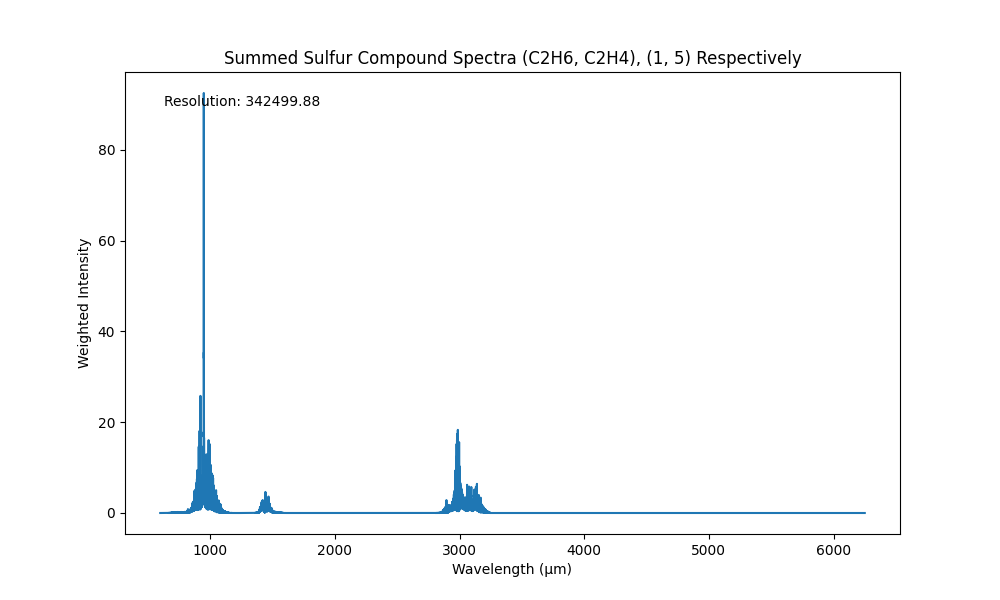

In [ ]:
# === PLOT RESULT ===
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, binned_abs)
plt.xlabel("Wavelength (µm)")
plt.ylabel("Weighted Intensity")
plt.title(f"Summed Sulfur Compound Spectra ({', '.join(molecules)}), ({', '.join([str(w) for w in weights])}) Respectively")

plt.text(0.05, 0.95,
         f"Resolution: {np.median(resolution):.2f}",
         transform=plt.gca().transAxes,
         verticalalignment='top')
plt.show()


# Add Poisson Noise, Normalize

In [ ]:
SNR = 1000

summed_abs_noisy = add_poisson_noise_snr(binned_abs, SNR)

for i in range(len(molecules)):
    molecule = list(molecules)[i]
    print(f'Adding Poisson noise to {molecule} spectrum with SNR = {SNR}')
    spectra[molecule]['spectrum_noisy'] = add_poisson_noise_snr(spectra[molecule]['absorbance'], SNR)

# plt.figure(figsize=(10, 6))
# plt.plot(bin_centers, summed_abs_noisy)
# plt.xlabel("Wavelength (µm)")
# plt.ylabel("Weighted Intensity with Poisson Noise")
# plt.title(f"Summed Sulfur Compound Spectra with Poisson Noise (SNR={SNR}) ({', '.join(molecules)}), ({', '.join([str(w) for w in weights])}) Respectively")
# plt.show()

Adding Poisson noise to C2H6 spectrum with SNR = 1000
Adding Poisson noise to C2H4 spectrum with SNR = 1000


In [ ]:
summed_abs_noisy_normalized = normalize_spectrum(summed_abs_noisy)

# Cross Correlation

In [ ]:
max_shift_cm1 = 2
max_shift_summed = int(max_shift_cm1/ wavenumber_bin)  # maximum shift, physically motivated

for i in range(len(molecules)):
    molecule = list(molecules)[i]
    weight = list(weights)[i]
    cross_correlation_vector_summed = correlate(summed_abs_noisy_normalized, normalize_spectrum(spectra[molecule]['spectrum_noisy']), mode='full')    
    lags_summed = signal.correlation_lags(len(summed_abs_noisy_normalized), len(spectra[molecule]['spectrum_noisy']), mode='full')
    lag_0_summed = len(summed_abs_noisy_normalized) - 1
    
    mask_summed = np.abs(lags_summed) <= max_shift_summed  
    similarity_summed = np.max(cross_correlation_vector_summed[mask_summed])
    spectra[molecule]['similarity_summed_noisy'] = similarity_summed
    spectra[molecule]['cross_correlation_vector_summed_noisy'] = cross_correlation_vector_summed
    spectra[molecule]['lags_summed'] = lags_summed
    spectra[molecule]['SNR_summed_noisy'] = similarity_summed / np.std(spectra[molecule]['cross_correlation_vector_summed_noisy'][mask_summed])
    print(f'{molecule} Similarity (summed noisy, weight={weight}): ', similarity_summed, "SNR: ", spectra[molecule]['SNR_summed_noisy'])

C2H6 Similarity (summed noisy, weight=1):  0.2841825665944701 SNR:  8.68004570799149
C2H4 Similarity (summed noisy, weight=5):  0.9726057126498321 SNR:  8.19225650400666


## Masked Cross Correlation

Computed masked cross-correlation for C2H6 spectrum in 2930-3045 cm^-1 range: Similarity (summed noisy, weight=1):  0.8050106287754671 SNR:  4.300020717617866
Computed masked cross-correlation for C2H4 spectrum in 2930-3045 cm^-1 range: Similarity (summed noisy, weight=5):  0.5804481949301377 SNR:  4.8336706835175045


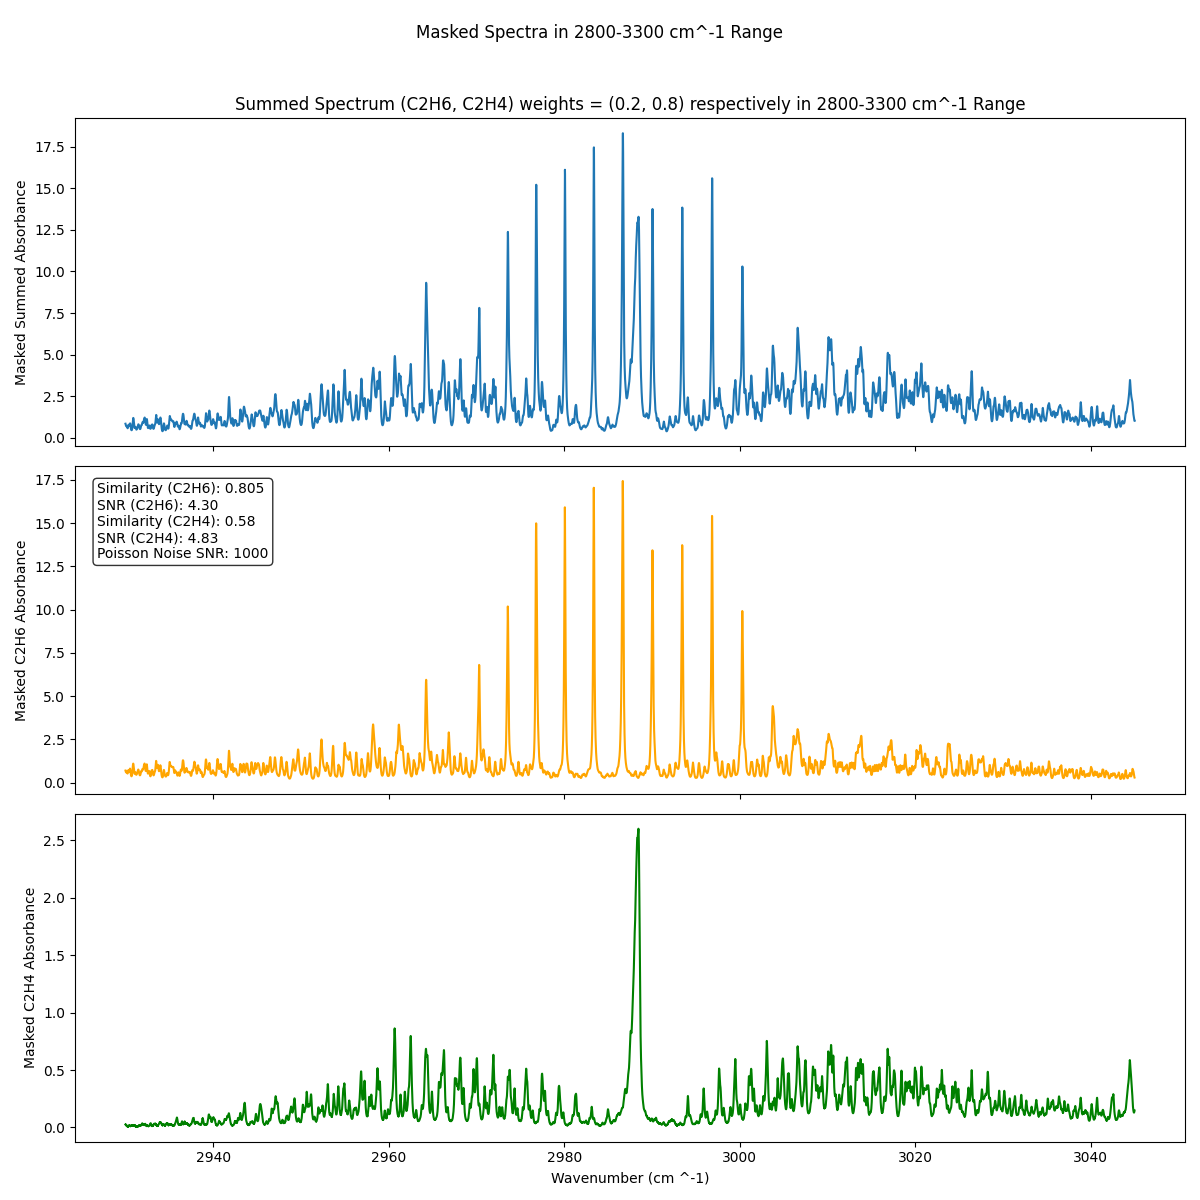

In [ ]:
wn_lo, wn_hi = 2930, 3045  # cm^-1
mask = (bin_centers >= wn_lo) & (bin_centers <= wn_hi)
wn_cut = bin_centers[mask]
summed_absorbance_cut  = summed_abs_noisy[mask]

max_shift_cm1 = 2

for i in range(len(molecules)):
    molecule = list(molecules)[i]
    weight = list(weights)[i]
    mask = (spectra[f'{molecule}']['wavenumber'] >= wn_lo) & (spectra[f'{molecule}']['wavenumber'] <= wn_hi)
    wn_cut = spectra[f'{molecule}']['wavenumber'][mask]
    test_absorbance_cut  = spectra[f'{molecule}']['spectrum_noisy'][mask]

    spectra[molecule]['cc_masked'] = correlate(normalize_spectrum(test_absorbance_cut), normalize_spectrum(summed_absorbance_cut), mode='full')
    lags_masked = signal.correlation_lags(len(test_absorbance_cut), len(summed_absorbance_cut), mode='full')
    spectra[molecule]['lags_masked'] = lags_masked
    lag_0_masked = len(test_absorbance_cut) - 1
    spectra[molecule]['lag_0_masked'] = lag_0_masked
    max_shift_masked = int(max_shift_cm1/ wavenumber_bin)  # maximum shift, physically motivated
    mask_masked = np.abs(lags_masked) <= max_shift_masked

    print(f'Computed masked cross-correlation for {molecule} spectrum in {wn_lo}-{wn_hi} cm^-1 range: Similarity (summed noisy, weight={weight}): ', np.max(spectra[molecule]['cc_masked'][mask_masked]), 'SNR: ', np.max(spectra[molecule]['cc_masked'][mask_masked])/np.std(spectra[molecule]['cc_masked'][mask_masked]))

fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axs[0].plot(wn_cut, summed_absorbance_cut, label='Summed Spectrum with Poisson Noise')
axs[0].set_ylabel('Masked Summed Absorbance')
axs[0].set_title('Summed Spectrum (C2H6, C2H4) weights = (0.2, 0.8) respectively in 2800-3300 cm^-1 Range')

axs[1].plot(wn_cut, spectra['C2H6']['spectrum_noisy'][mask], label='C2H6 Spectrum range 2800-3300 cm^-1 with Poisson Noise', color='orange')
axs[1].set_ylabel('Masked C2H6 Absorbance')

axs[2].plot(wn_cut, spectra['C2H4']['spectrum_noisy'][mask], label='C2H4 Spectrum range 2800-3300 cm^-1 with Poisson Noise', color='green')
axs[2].set_ylabel('Masked C2H4 Absorbance')

axs[1].text(
    0.02, 0.95,
    f"Similarity (C2H6): {np.max(spectra['C2H6']['cc_masked'][mask_masked]):.3g}\n"
    f"SNR (C2H6): {np.max(spectra['C2H6']['cc_masked'][mask_masked])/np.std(spectra['C2H6']['cc_masked'][mask_masked]):.2f}\n"
    f"Similarity (C2H4): {np.max(spectra['C2H4']['cc_masked'][mask_masked]):.3g}\n"
    f"SNR (C2H4): {np.max(spectra['C2H4']['cc_masked'][mask_masked])/np.std(spectra['C2H4']['cc_masked'][mask_masked]):.2f}\n"
    f"Poisson Noise SNR: {SNR}",
    transform=axs[1].transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.xlabel('Wavenumber (cm ^-1)')
plt.suptitle('Masked Spectra in 2800-3300 cm^-1 Range')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

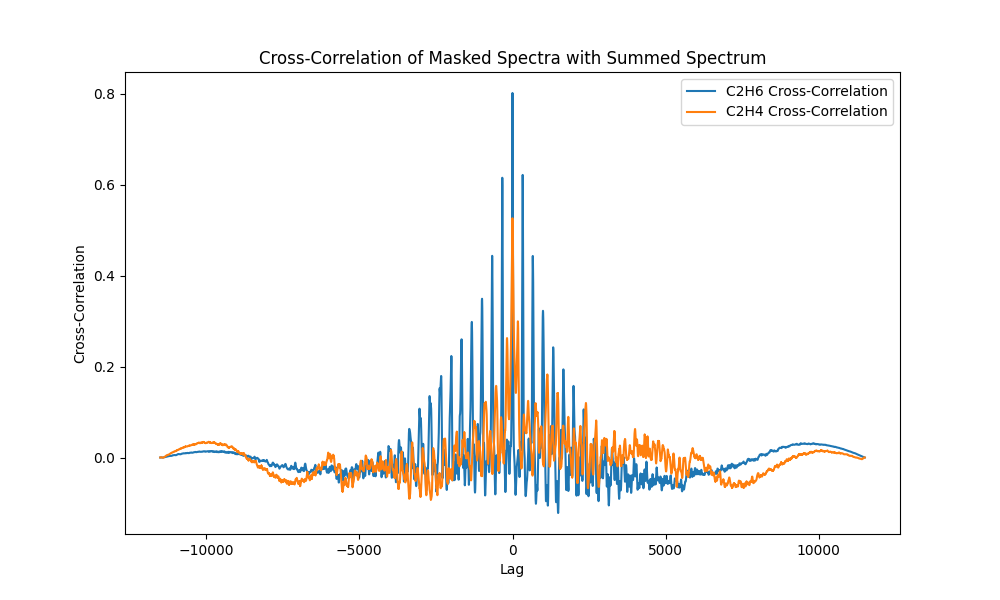

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(spectra['C2H6']['lags_masked'], spectra['C2H6']['cc_masked'], label='C2H6 Cross-Correlation')
plt.plot(spectra['C2H4']['lags_masked'], spectra['C2H4']['cc_masked'], label='C2H4 Cross-Correlation')
# plt.axvline(x=np.argmax(spectra['C2H6']['cc_masked']) - spectra['C2H6']['lag_0_masked'], color='orange', linestyle='--', label='C2H6 Max CC Lag')
plt.xlabel("Lag")
plt.ylabel("Cross-Correlation")
plt.title("Cross-Correlation of Masked Spectra with Summed Spectrum")
plt.legend()
plt.show()

# Plots

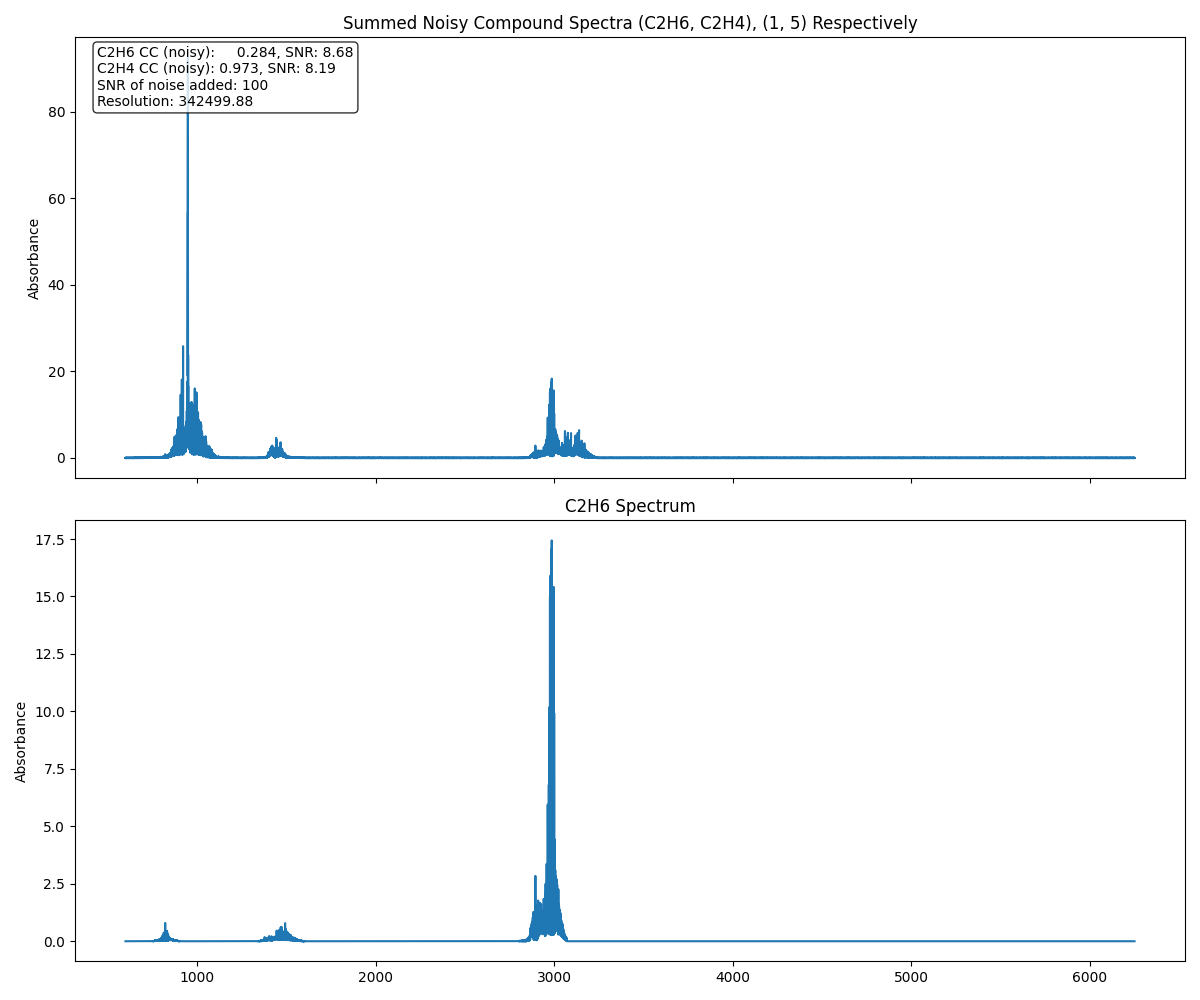

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# test_peaks = find_troughs_wn(template_wn_grid, test_absorbance, prominence=prom, distance=dist)
# test_peaks_absorbance = [test_absorbance[np.where(template_wn_grid == wn)[0][0]] for wn in test_peaks]

# summed_peaks = find_troughs_wn(template_wn_grid, summed_abs_noisy, prominence=prom, distance=dist)
# summed_peaks_absorbance = [summed_abs_noisy[np.where(template_wn_grid == wn)[0][0]] for wn in summed_peaks]

# fig.suptitle('Spectra for Cross-Correlation')

axs[0].plot(bin_centers, summed_abs_noisy)
axs[0].set_ylabel('Absorbance')
axs[0].set_title(f"Summed Noisy Compound Spectra ({', '.join(molecules)}), ({', '.join([str(w) for w in weights])}) Respectively")


# axs[0].plot(template_wn_grid, summed_abs_noisy, label="Summed, Weighted")
# axs[0].scatter(
#     summed_peaks,
#     summed_peaks_absorbance,
#     s=25, marker="o", color="red", label="Detected peaks"
# )


axs[1].plot(wn_grid, spectra['C2H6']['absorbance'])
axs[1].set_ylabel('Absorbance')
axs[1].set_title(f'C2H6 Spectrum')

# axs[1].plot(template_wn_grid, test_absorbance_noisy, label="Test")
# axs[1].scatter(
#     test_peaks,
#     test_peaks_absorbance,
#     s=25, marker="o", color="red", label="Detected peaks"
# )


cc_text = (
    f"C2H6 CC (noisy):     {spectra['C2H6']['similarity_summed_noisy']:.3g}, SNR: {spectra['C2H6']['SNR_summed_noisy']:.2f}\n"
    # f"CH3OH CC (noisy):     {spectra['CH3OH']['similarity_summed_noisy']:.3g}, SNR: {spectra['CH3OH']['SNR_summed_noisy']:.2f}\n"
    f"C2H4 CC (noisy): {spectra['C2H4']['similarity_summed_noisy']:.3g}, SNR: {spectra['C2H4']['SNR_summed_noisy']:.2f}\n"
    # f"CS2 CC (noisy): {spectra['CS2']['similarity_summed_noisy']:.3g}, SNR: {spectra['CS2']['SNR_summed_noisy']:.2f}\n"
    f"SNR of noise added: {SNR}\n"
    f"Resolution: {np.median(resolution):.2f}"

)

axs[0].text(
    0.02, 0.98, cc_text,
    transform=axs[0].transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)


plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 1, 0.96])  # leaves room for suptitle


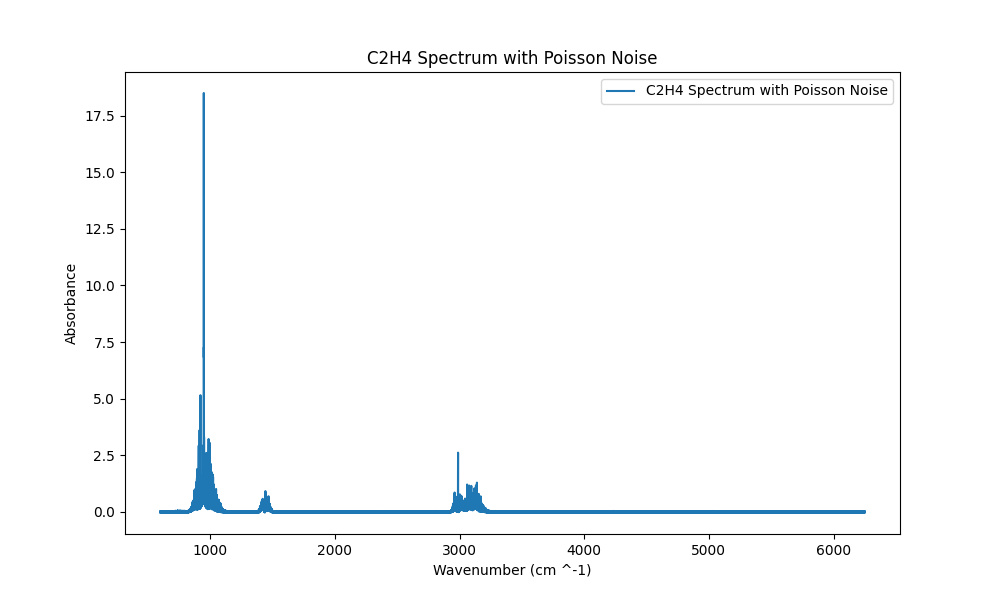

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(spectra['C2H4']['wavenumber'], spectra['C2H4']['spectrum_noisy'], label='C2H4 Spectrum with Poisson Noise')
plt.xlabel("Wavenumber (cm ^-1)")
plt.ylabel("Absorbance")
plt.title("C2H4 Spectrum with Poisson Noise")
plt.legend()
plt.show()

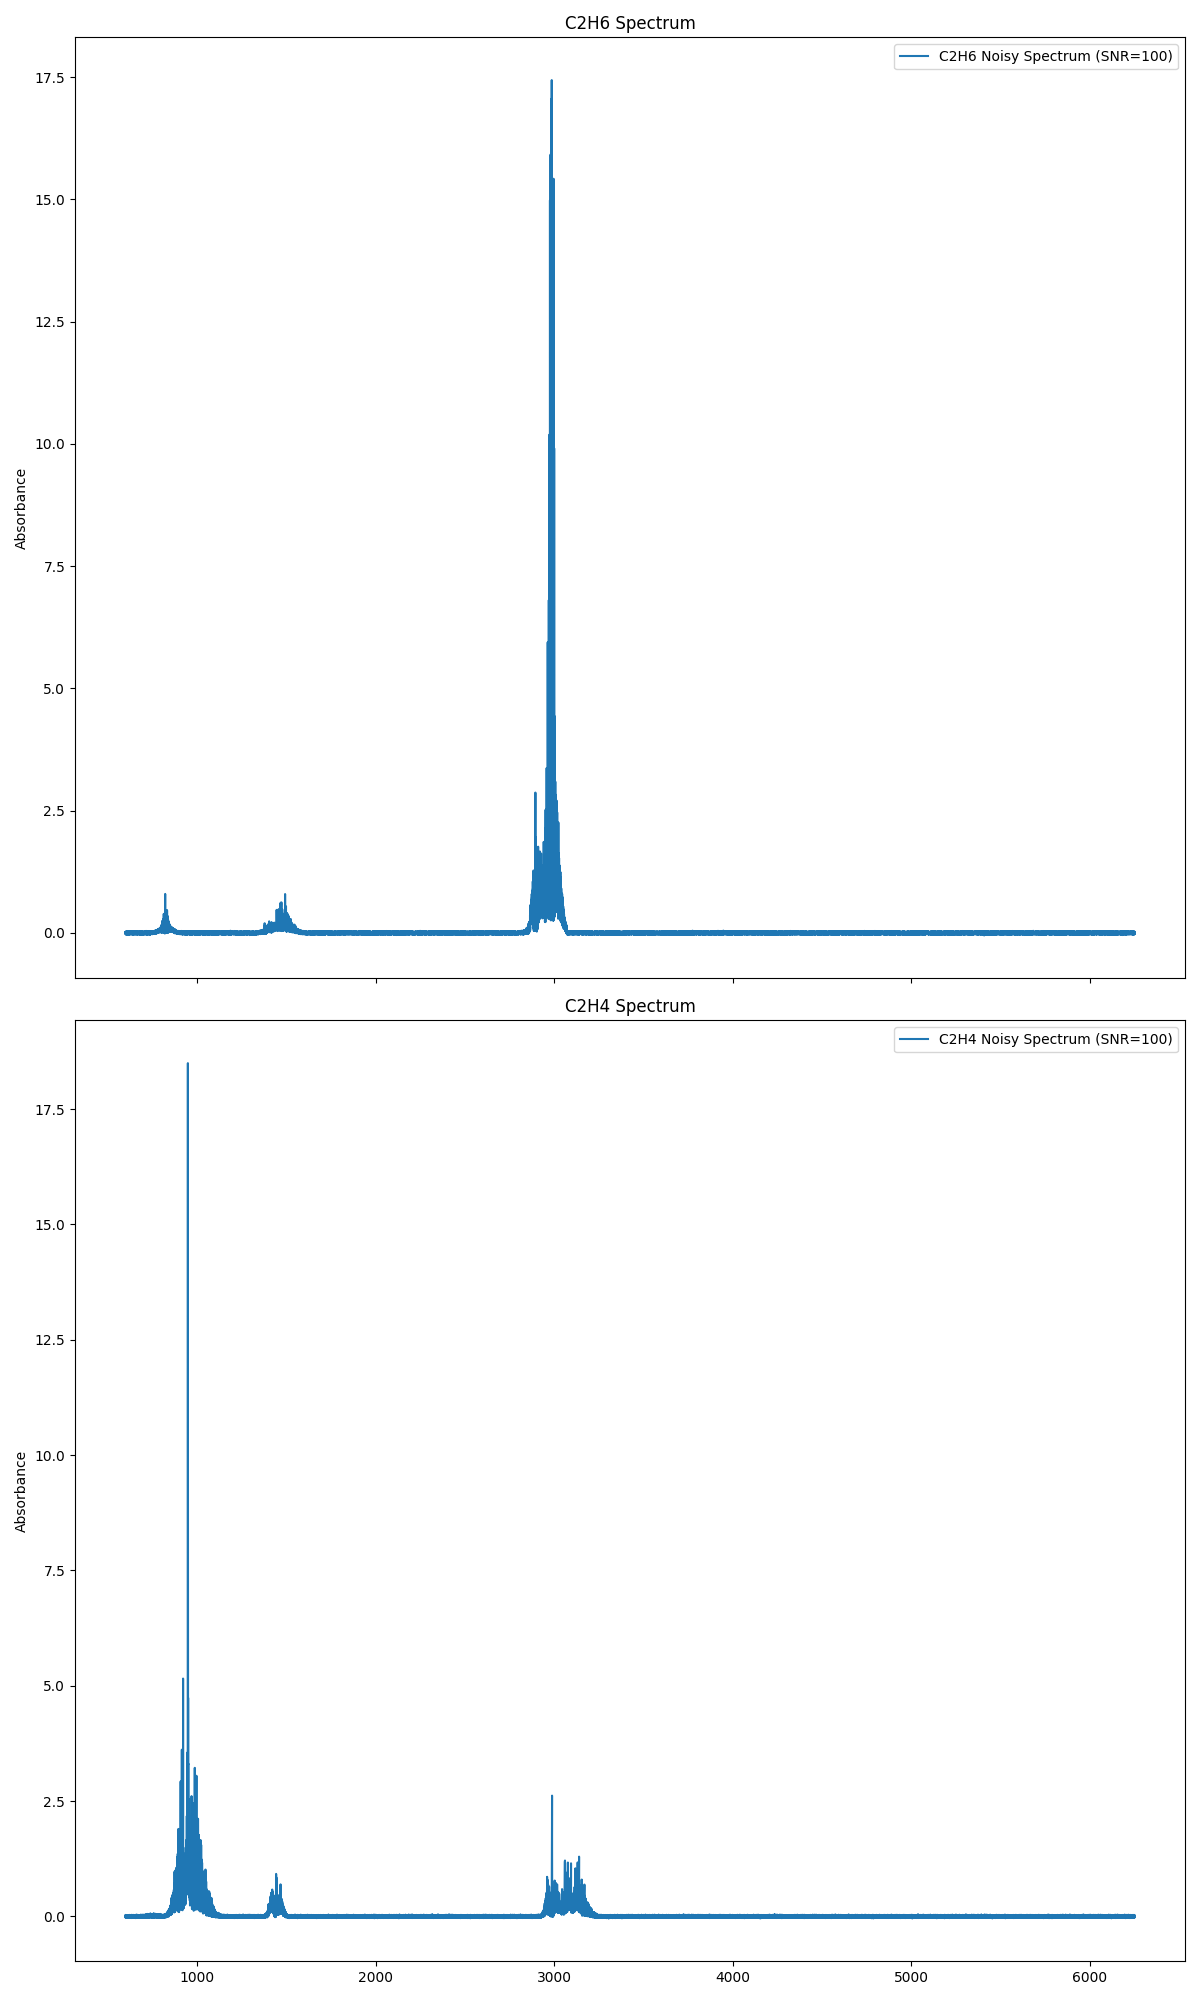

In [ ]:
fig, axs = plt.subplots(len(molecule_weights.keys()), 1, figsize=(12, 20), sharex=True)

for i in molecule_weights.keys():
    if molecule_weights[i] != 0:
        axs[list(molecule_weights.keys()).index(i)].plot(spectra[i]['wavenumber'], spectra[i]['spectrum_noisy'], label=f'{i} Noisy Spectrum (SNR={SNR})')
        axs[list(molecule_weights.keys()).index(i)].set_title(f'{i} Spectrum')
        # axs[list(molecule_weights.keys()).index(i)].set_xlabel('Wavenumber (cm ^-1)')
        axs[list(molecule_weights.keys()).index(i)].set_ylabel('Absorbance')
        axs[list(molecule_weights.keys()).index(i)].legend()
plt.tight_layout()

# # plt.plot(spectra['CH3Br']['wavenumber'], spectra['CH3Br']['absorbance'], label='CH3Br Spectrum')
# axs[0].plot(spectra['CH3I']['wavenumber'], spectra['CH3I']['absorbance'], label='CH3I Noisy Spectrum (SNR={SNR})')
# axs[0].set_title('CH3I Spectrum')
# axs[0].set_xlabel('Wavenumber (cm ^-1)')
# axs[0].set_ylabel('Absorbance')
# axs[0].legend()

# axs[1].plot(spectra['CH3F']['wavenumber'], spectra['CH3F']['absorbance'], label='CH3F Noisy Spectrum (SNR={SNR})', color='orange')
# axs[1].set_title('CH3F Spectrum')
# axs[1].set_xlabel('Wavenumber (cm ^-1)')
# axs[1].set_ylabel('Absorbance')
# axs[1].legend()

# Looping

In [ ]:
results = []

wavenumber_bins_for_loop = [1, 0.1, 0.01, 0.001]

molecule_indices = {
    # "SO": 50,
    # # "S2": 58,
    # "SO2": 9,
    # "SO3": 47,
    # "H2S": 31,
    # "OCS": 19,
    # "CS2": 53,
    # "CS": 46
    # "CH4": 6,
    "C2H2" : 26,
    "C2H6" : 27,
    "C2H4" : 38, 
    # "CH3OH" : 39, 
    # "CH3Br" : 40, 
    # "CH3CN" : 41, 
    # "C4H2": 43, 
    # "CH3F" : 51, 
    # "CH3I" : 54, 
    # "CH3" : 57
}

molecule_weights = {
    # "SO2" : 1,
    # "SO3" : 1,
    # "H2S" : 1,
    # "OCS" : 0,
    # "CS" : 1,
    # "CS2" : 0,
    # "SO" : 1
    # "CH4": 0,
    # "C2H2" : 1,
    "C2H6" : 1,
    "C2H4" : 5, 
    # "CH3OH" : 1, 
    # "CH3Br" : 1, 
    # "CH3CN" : 1, 
    # "C4H2": 0, 
    # "CH3F" : 1, 
    # "CH3I" : 1, 
    # "CH3" : 1
}

snr_to_test = [1,5,10,50,100,500,1000]

# === PARAMETERS ===
wl_min = 1.6                  # min wavelength in µm
wl_max = 16.6667               # max wavelength in µm

wn_min = 1e4 / wl_max         # min wavenumber in cm^-1
wn_max = 1e4 / wl_min         # max wavenumber in cm^-1

for i in range(len(wavenumber_bins_for_loop)):

    #Parsing Data________________________________________________________________________________________________________________________________________________
    wavenumber_bin = wavenumber_bins_for_loop[i]
    print(f'Wavenumber bin size: {wavenumber_bin} cm^-1')

    spectra = generate_absorbance_library(
    molecule_indices,
    lam_min_um=1.6,
    lam_max_um=16.6667, dwn=wavenumber_bin)

    for mol in spectra.keys():
        print(mol, 'dwn actual = ', np.median(np.diff(spectra[mol]['wavenumber'])))

    #Creating Summed Spectrum______________________________________________________________________________________________________________________________

    bin_width = wavenumber_bin             # bin width in cm^-1

    # === OUTPUT ARRAYS ===
    bin_edges = np.arange(wn_min, wn_max + bin_width, bin_width)
    binned_abs = np.zeros(len(bin_edges)-1)

    molecules = list(molecule_weights.keys())
    weights = molecule_weights  # dict
    weight = weights[molecule]

    resolution_median_by_molecule = {}

    # === MAIN LOOP ===
    for molecule in molecules:
        
        weight = molecule_weights[molecule]
        # molecule_index = molecule_indices[molecule]
        # filepath = os.path.join(data_folder, filename)

        # === PARSE FILE ===

        absorbance = spectra[molecule]['absorbance']
        wn_grid = spectra[molecule]['wavenumber']

        wn_array = np.array(wn_grid)
        absorbance = np.array(absorbance) * weight
        print(f"{molecule}: wavenumber range = {wn_array.min():.6f} – {wn_array.max():.6f} µm")
        print('absorbance =', absorbance)

        # === BIN BY WAVELENGTH ===
        hist, _ = np.histogram(wn_array, bins=bin_edges, weights=absorbance)
        binned_abs += hist

        resolution = wn_array / np.median(np.diff(wn_array))
        resolution_median_by_molecule[molecule] = np.median(resolution)
        print(f"{molecule}: spectral resolution = {np.median(resolution):.2f}")

    #Apply Poisson Noise______________________________________________________________________________________________________________________________

    for snr in snr_to_test:
        print(f'Adding Poisson noise to summed spectrum with SNR = {snr}')
        summed_abs_noisy = add_poisson_noise_snr(binned_abs, snr)
        summed_abs_noisy_normalized = normalize_spectrum(summed_abs_noisy)

        # plt.figure(figsize=(10, 6))
        # plt.plot(bin_centers, summed_abs_noisy)
        # plt.xlabel("Wavelength (µm)")
        # plt.ylabel("Weighted Intensity with Poisson Noise")
        # plt.title(f"Summed Sulfur Compound Spectra with Poisson Noise (SNR={snr}) ({', '.join(molecules)}), ({', '.join([str(w) for w in weights])}) Respectively")
        # plt.show()

        #Store Noisy Spectra______________________________________________________________________________________________________________________________

        for i in range(len(molecules)):
            molecule = list(molecules)[i]
            print(f'Adding Poisson noise to {molecule} spectrum with SNR = {snr}')
            spectra[molecule][f'spectrum_noisy'] = add_poisson_noise_snr(spectra[molecule]['absorbance'], snr)


        max_shift_cm1 = 2
        max_shift_summed = int(max_shift_cm1/ wavenumber_bin)  # maximum shift, physically motivated

        for i in range(len(molecules)):
            molecule = list(molecules)[i]
            weight = list(weights)[i]
            cross_correlation_vector_summed = correlate(summed_abs_noisy_normalized, normalize_spectrum(spectra[molecule][f'spectrum_noisy']), mode='full')    
            lags_summed = signal.correlation_lags(len(summed_abs_noisy_normalized), len(spectra[molecule][f'spectrum_noisy']), mode='full')
            lag_0_summed = len(summed_abs_noisy_normalized) - 1
            
            mask_summed = np.abs(lags_summed) <= max_shift_summed  
            similarity_summed = np.max(cross_correlation_vector_summed[mask_summed])
            spectra[molecule][f'similarity_summed_noisy_snr_{snr}'] = similarity_summed
            spectra[molecule][f'cross_correlation_vector_summed_noisy_snr_{snr}'] = cross_correlation_vector_summed
            spectra[molecule][f'lags_summed_snr_{snr}'] = lags_summed
            spectra[molecule][f'SNR_summed_noisy_snr_{snr}'] = similarity_summed / np.std(spectra[molecule][f'cross_correlation_vector_summed_noisy_snr_{snr}'][mask_summed])

            results.append({
                'molecule': molecule,
                'wavenumber_bin': wavenumber_bin,
                'Resolution' : resolution_median_by_molecule[molecule],
                'weight': weight,
                'input snr': snr,
                'similarity_summed_noisy': similarity_summed,
                'similarity_snr': spectra[molecule][f'SNR_summed_noisy_snr_{snr}']
            })

            # print(f'{molecule} Similarity (summed noisy SNR={snr}, weight={weight}): ', similarity_summed, "SNR: ", spectra[molecule][f'SNR_summed_noisy_snr_{snr}'])

    


Wavenumber bin size: 1 cm^-1
Trying: C2H2 26

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: C2H2
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  65536 bytes written to ./C2H2.data
  655

/Users/zaniaccollins/Desktop/SGL/Python/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


28.135649 seconds elapsed for abscoef; nlines = 60546
C2H2: λ = 1.600–16.667 µm, abs max = 6.624e+01
Trying: C2H6 27

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: C2H6
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536 bytes written to ./C2H6.data
  65536

/Users/zaniaccollins/Desktop/SGL/Python/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


21.451200 seconds elapsed for abscoef; nlines = 52648
C2H6: λ = 1.600–16.667 µm, abs max = 9.497e+00
Trying: C2H4 38

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: C2H4
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536 bytes written to ./C2H4.data
  65536

/Users/zaniaccollins/Desktop/SGL/Python/hapi.py:35497: UserWarning: Big wavenumber step: possible accuracy decline
  warn('Big wavenumber step: possible accuracy decline')


14.357563 seconds elapsed for abscoef; nlines = 59536
C2H4: λ = 1.600–16.667 µm, abs max = 7.219e+00
C2H2 dwn actual =  1.0
C2H6 dwn actual =  1.0
C2H4 dwn actual =  1.0
C2H6: wavenumber range = 599.998800 – 6249.998800 µm
absorbance = [-0. -0. -0. ... -0. -0. -0.]
C2H6: spectral resolution = 3425.00
C2H4: wavenumber range = 599.998800 – 6249.998800 µm
absorbance = [-0. -0. -0. ... -0. -0. -0.]
C2H4: spectral resolution = 3425.00
Adding Poisson noise to summed spectrum with SNR = 1
Adding Poisson noise to C2H6 spectrum with SNR = 1
Adding Poisson noise to C2H4 spectrum with SNR = 1
Adding Poisson noise to summed spectrum with SNR = 5
Adding Poisson noise to C2H6 spectrum with SNR = 5
Adding Poisson noise to C2H4 spectrum with SNR = 5
Adding Poisson noise to summed spectrum with SNR = 10
Adding Poisson noise to C2H6 spectrum with SNR = 10
Adding Poisson noise to C2H4 spectrum with SNR = 10
Adding Poisson noise to summed spectrum with SNR = 50
Adding Poisson noise to C2H6 spectrum with S

In [ ]:
df = pd.DataFrame(results)
df

,molecule,wavenumber_bin,Resolution,weight,input snr,similarity_summed_noisy,similarity_snr
0,C2H6,1.000,3.424999e+03,C2H6,1,0.067243,5.333960
1,C2H4,1.000,3.424999e+03,C2H4,1,0.131395,8.870655
2,C2H6,1.000,3.424999e+03,C2H6,5,0.226033,5.616126
3,C2H4,1.000,3.424999e+03,C2H4,5,0.676839,9.394864
4,C2H6,1.000,3.424999e+03,C2H6,10,0.282048,5.652809
5,C2H4,1.000,3.424999e+03,C2H4,10,0.864928,9.040312
6,C2H6,1.000,3.424999e+03,C2H6,50,0.297851,5.540475
7,C2H4,1.000,3.424999e+03,C2H4,50,0.967985,9.028656
8,C2H6,1.000,3.424999e+03,C2H6,100,0.297566,5.484692
9,C2H4,1.000,3.424999e+03,C2H4,100,0.972359,8.966410
